#泰坦尼克号数据清洗与生存分析

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

1.数据导入与基本探索

In [3]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


2.数据清洗

In [4]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df['Age']=df.groupby(['Sex','Pclass'])['Age'].transform(lambda x:x.fillna(x.median()))

In [6]:
df = df.dropna(subset=['Embarked'])
df['Cabin']=df['Cabin'].notnull().astype(int)

In [15]:
sum(df.duplicated())

0

3.数据分析

In [19]:
sum(df['Survived'])/len(df['Survived'])

0.38245219347581555

In [25]:
df.groupby('Sex')['Survived'].mean()

Sex
female    0.740385
male      0.188908
Name: Survived, dtype: float64

In [26]:
df.groupby('Pclass')['Survived'].mean()

Pclass
1    0.626168
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [34]:
group_age = ['Youth','YouthAdult','MiddleAged','Senior']
df['AgeGroup']=pd.cut(df['Age'],[0,12,35,60,float('inf')],include_lowest=True,right=True,labels=group_age)
df.groupby('AgeGroup')['Survived'].mean()

AgeGroup
Youth         0.579710
YouthAdult    0.366438
MiddleAged    0.381395
Senior        0.190476
Name: Survived, dtype: float64

4.可视化

Text(0, 0.5, '存活率')

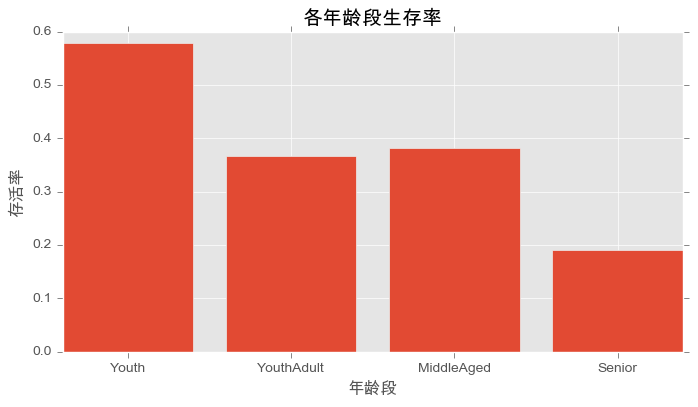

In [46]:
plt.rcParams['font.family'] = 'Arial Unicode MS'  
plt.style.use('ggplot')
fig,ax=plt.subplots(figsize=(8,4),dpi=100)
PS=df.groupby('AgeGroup')['Survived'].mean()
x=PS.index
y=PS.values
ax.bar(x,y)
ax.set_title('各年龄段生存率')
ax.set_xlabel('年龄段')
ax.set_ylabel('存活率')

Text(0, 0.5, '生存率')

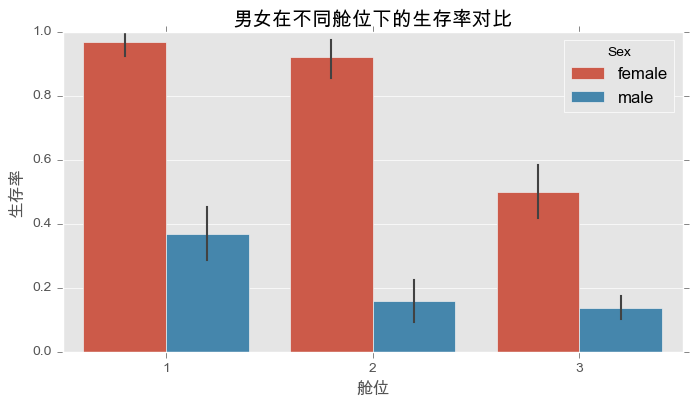

In [47]:
fx,ax = plt.subplots(figsize=(8,4),dpi=100)
sns.barplot(data=df,x='Pclass',y='Survived',hue='Sex',ax=ax)
ax.set_title('男女在不同舱位下的生存率对比')
ax.set_xlabel('舱位')
ax.set_ylabel('生存率')

Text(0, 0.5, '人数')

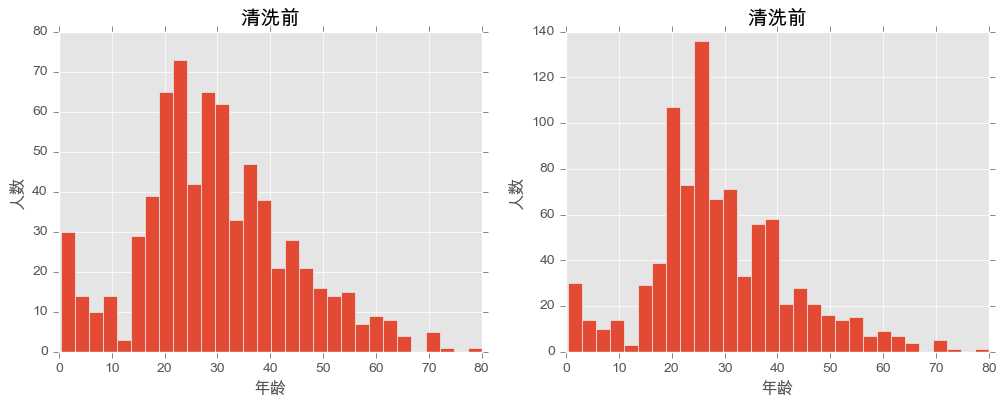

In [65]:
fx,(ax1,ax2) = plt.subplots(1,2,figsize=(12,4),dpi=100)
plt.style.use('ggplot')
ax1.hist(df1['Age'], bins=30)
ax1.set_title('清洗前')
ax1.set_xlabel('年龄')
ax1.set_ylabel('人数')

ax2.hist(df['Age'],bins=30)
ax2.set_title('清洗前')
ax2.set_xlabel('年龄')
ax2.set_ylabel('人数')

5.结论

各舱位女性存活率显著高于男性存活率,孩子的存活率显著高于成人的存活率,伟大,无需多言
高级舱位的存活率显著高于低级舱位的存活率,可能是因为高级舱位的位置相比于低级舱位更有利于出逃